## Dự đoán Aggregate Rating nhà hàng theo mô hình RandomForest

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import utils
importlib.reload(utils)

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from utils import check_overfitting

REVIEW DATASET SAU KHI ĐÃ XỬ LÍ 

In [96]:
df = pd.read_csv('../../data/processed/clean_ds_train_data.csv')
df_model = df.copy()

# Tạo nhãn khoảng
bins = [0, 3.0, 4.0, 5.0]
labels = [0, 1, 2]
label_names = ['Thấp (< 3.0)', 'Trung bình (3.0–4.0)', 'Tốt (≥ 4.0)']

rating_class = pd.cut(df_model['Aggregate rating'], bins=bins, labels=labels, include_lowest=True).astype(int)

print('Aggregate rating phân bố theo các khoảng:')
counts = rating_class.value_counts().sort_index()
for i, cnt in counts.items():
    print(f'  Khoảng {i} ({label_names[i]}): {cnt} mẫu ({cnt/len(rating_class)*100:.1f}%)')

Aggregate rating phân bố theo các khoảng:
  Khoảng 0 (Thấp (< 3.0)): 1901 mẫu (25.7%)
  Khoảng 1 (Trung bình (3.0–4.0)): 4388 mẫu (59.3%)
  Khoảng 2 (Tốt (≥ 4.0)): 1114 mẫu (15.0%)


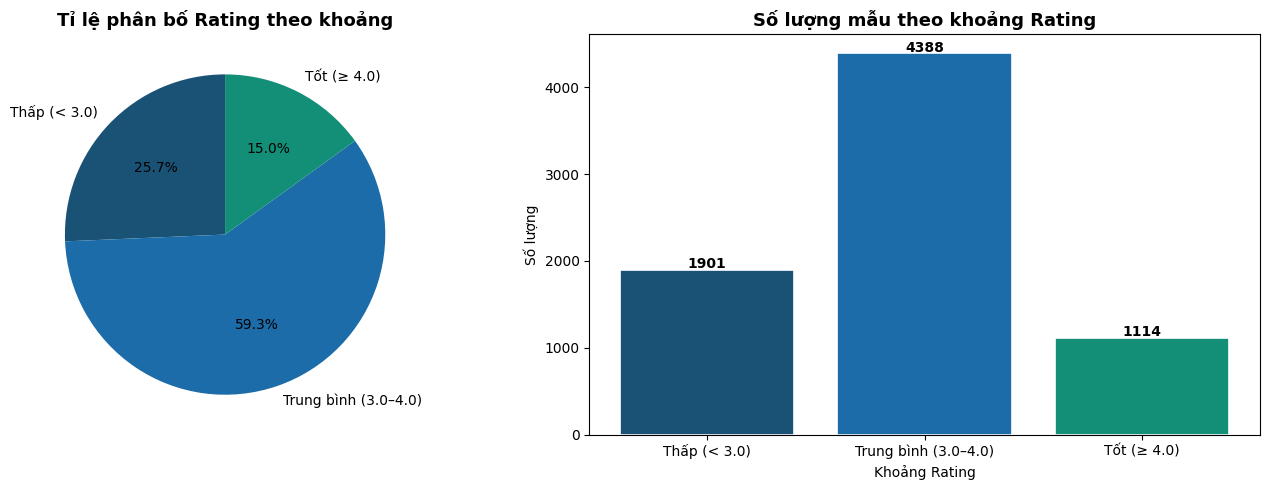

In [97]:
# Visualize 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1a5276', '#1b6ca8', '#148f77']
counts_vals = [counts[i] for i in range(3)]  

axes[0].pie(counts_vals, labels=label_names, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Tỉ lệ phân bố Rating theo khoảng', fontsize=13, fontweight='bold')

bars = axes[1].bar(label_names, counts_vals, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Số lượng mẫu theo khoảng Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Khoảng Rating')
axes[1].set_ylabel('Số lượng')
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

CHỌN ĐẶC TRƯNG CẦN DÙNG VÀ TÁCH DATATSET


In [98]:
target = 'Aggregate rating' 
features = [col for col in df_model.columns if col != target]

X = df_model[features]
y_c  = rating_class
y_r = df_model['Aggregate rating']

print(f'Số features: {len(features)}')
print(f'Số samples: {len(X)}')

Số features: 10
Số samples: 7403


In [99]:
X_train_c, X_valid_c, y_train_c, y_valid_c = train_test_split(
    X, y_c,
    test_size=0.2,
    random_state=42,
    stratify=y_c  
)

print(f'Train set: {X_train_c.shape[0]} mẫu')
print(f'Valid set: {X_valid_c.shape[0]} mẫu')

Train set: 5922 mẫu
Valid set: 1481 mẫu


In [100]:
X_train_r, X_valid_r, y_train_r, y_valid_r = train_test_split(
    X, y_r,
    test_size=0.2,
    random_state=42
)

print(f'Train set: {X_train_r.shape[0]} mẫu')
print(f'Valid set: {X_valid_r.shape[0]} mẫu')

Train set: 5922 mẫu
Valid set: 1481 mẫu


HUẤN LUYỆN MÔ HÌNH RANDOM FOREST CLASSIFIER

In [101]:
rf_model_c = RandomForestClassifier(
    n_estimators=200,          # Giữ nguyên số cây
    max_depth=8,               # QUAN TRỌNG: Giới hạn độ sâu để ngăn học vẹt (thử từ 5-10)
    min_samples_split=10,      # QUAN TRỌNG: Phải có ít nhất 10 mẫu mới được tách nhánh
    min_samples_leaf=5,        # QUAN TRỌNG: Mỗi lá phải có ít nhất 5 mẫu
    class_weight='balanced',   # Giữ nguyên để cân bằng dữ liệu
    max_features='sqrt',       # Chỉ xét căn bậc hai số đặc trưng mỗi lần (tăng tính đa dạng)
    n_jobs=-1,                 # Dùng toàn bộ nhân CPU
    random_state=42         
)

# Huấn luyện
rf_model_c.fit(X_train_c, y_train_c)
print('Huấn luyện mô hình random forest classifier hoàn tất!')

Huấn luyện mô hình random forest classifier hoàn tất!


ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST CLASSIFIER

In [102]:
# Dự báo trên tập X_valid
y_pred_c = rf_model_c.predict(X_valid_c)

acc = accuracy_score(y_valid_c, y_pred_c)
f1_macro = f1_score(y_valid_c, y_pred_c, average='macro')
f1_weighted = f1_score(y_valid_c, y_pred_c, average='weighted')


print(f'Accuracy       : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 (macro)     : {f1_macro:.4f}')
print(f'F1 (weighted)  : {f1_weighted:.4f}')

print()
print('Classification Report:')
print(classification_report(
    y_valid_c, 
    y_pred_c, 
    target_names=['Thấp', 'Trung bình', 'Tốt'] 
))

Accuracy       : 0.6509 (65.09%)
F1 (macro)     : 0.6555
F1 (weighted)  : 0.6528

Classification Report:
              precision    recall  f1-score   support

        Thấp       0.52      0.75      0.61       380
  Trung bình       0.79      0.57      0.66       878
         Tốt       0.60      0.82      0.70       223

    accuracy                           0.65      1481
   macro avg       0.64      0.71      0.66      1481
weighted avg       0.69      0.65      0.65      1481



In [103]:
# Đánh giá theo Cross-validation 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model_c, X, y_c, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'\nCross-Validation (5-fold) F1 macro:')
print(f'Scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean  : {cv_scores.mean():.4f}')
print(f'Std   : {cv_scores.std():.4f}')


Cross-Validation (5-fold) F1 macro:
Scores: [np.float64(0.6416), np.float64(0.6553), np.float64(0.6457), np.float64(0.6482), np.float64(0.6343)]
Mean  : 0.6450
Std   : 0.0070


KIỂM TRA OVERFITTING CHO CLASSIFICATION

In [104]:
check_overfitting(rf_model_c, X_train_c, y_train_c, X_valid_c, y_valid_c, task='classification')

Kiểm tra Overfitting cho mô hình: classification
Accuracy - Train: 0.7023, Valid: 0.6509
Mô hình ổn định


CONFUSION MATRIX RANDOM FOREST CLASSIFIER

In [105]:
cm = confusion_matrix(y_valid_c, y_pred_c)

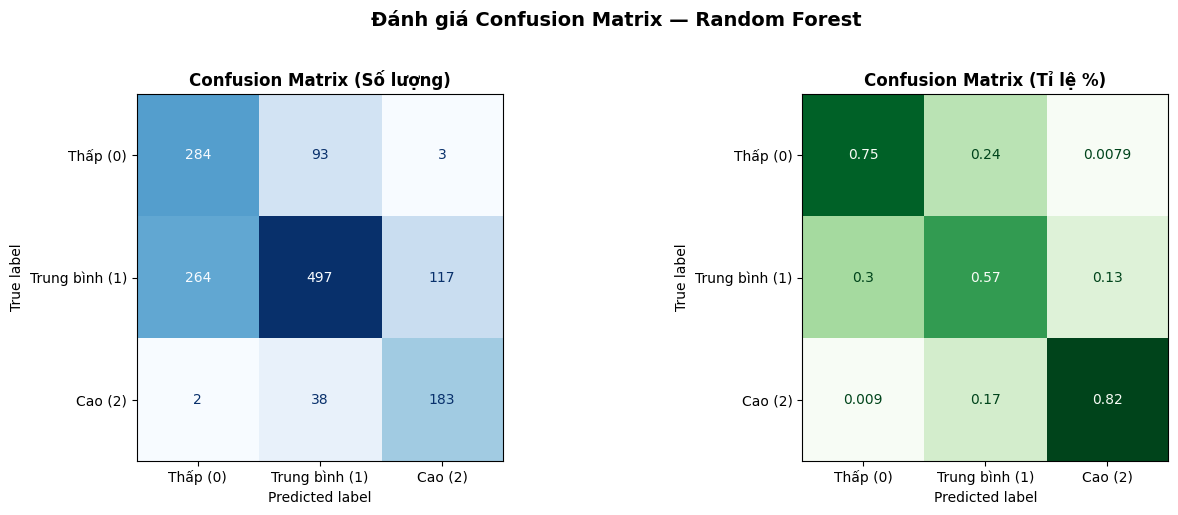

In [106]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Ma trận số lượng
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Cao (2)'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Số lượng)', fontweight='bold')

# Ma trận tỉ lệ %
cm_norm = confusion_matrix(y_valid_c, y_pred_c, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=['Thấp (0)', 'Trung bình (1)', 'Cao (2)'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Tỉ lệ %)', fontweight='bold')

plt.suptitle('Đánh giá Confusion Matrix — Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

HUẤN LUYỆN MÔ HÌNH RANDOM FOREST REGRESSOR

In [107]:
rf_model_r = RandomForestRegressor(
n_estimators=150,
    max_depth=6,           # Hạn chế độ sâu để chống học vẹt
    min_samples_split=10,  # Mỗi nhánh phải có ít nhất 10 mẫu (giảm chi tiết nhiễu)
    min_samples_leaf=5,    # Mỗi lá phải có ít nhất 5 mẫu
    n_jobs=-1,
    random_state=42
)

rf_model_r.fit(X_train_r, y_train_r)
print('Huấn luyện random forest regressor hoàn tất!')

Huấn luyện random forest regressor hoàn tất!


ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST REGRESSOR

In [108]:
y_pred_r = rf_model_r.predict(X_valid_r)

mae = mean_absolute_error(y_valid_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_valid_r, y_pred_r))
r2 = r2_score(y_valid_r, y_pred_r)

print(f'Mean Abs Error (MAE)  : {mae:.4f}')
print(f'Root Mean Sq E (RMSE) : {rmse:.4f}')
print(f'R-squared      (R²)   : {r2:.4f}')
print(f'\nÝ nghĩa: Trung bình dự đoán sai lệch ±{mae:.3f} điểm so với thực tế')

Mean Abs Error (MAE)  : 0.2592
Root Mean Sq E (RMSE) : 0.3480
R-squared      (R²)   : 0.6084

Ý nghĩa: Trung bình dự đoán sai lệch ±0.259 điểm so với thực tế


In [109]:
# Đánh giá theo Cross-validation
cv_r = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_r_mae = cross_val_score(rf_model_r, X, y_r, cv=cv_r, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_scores_r_r2 = cross_val_score(rf_model_r, X, y_r, cv=cv_r, scoring='r2', n_jobs=-1)

print('Cross-Validation (5-fold) — Regressor:')
print(f'MAE Scores  : {[round(-s, 4) for s in cv_scores_r_mae]}')
print(f'MAE Mean    : {-cv_scores_r_mae.mean():.4f} ± {cv_scores_r_mae.std():.4f}')
print(f'R² Scores   : {[round(s, 4) for s in cv_scores_r_r2]}')
print(f'R² Mean     : {cv_scores_r_r2.mean():.4f} ± {cv_scores_r_r2.std():.4f}')

Cross-Validation (5-fold) — Regressor:
MAE Scores  : [np.float64(0.2593), np.float64(0.2846), np.float64(0.2639), np.float64(0.2624), np.float64(0.2679)]
MAE Mean    : 0.2676 ± 0.0089
R² Scores   : [np.float64(0.6087), np.float64(0.5295), np.float64(0.5647), np.float64(0.5853), np.float64(0.5746)]
R² Mean     : 0.5725 ± 0.0260


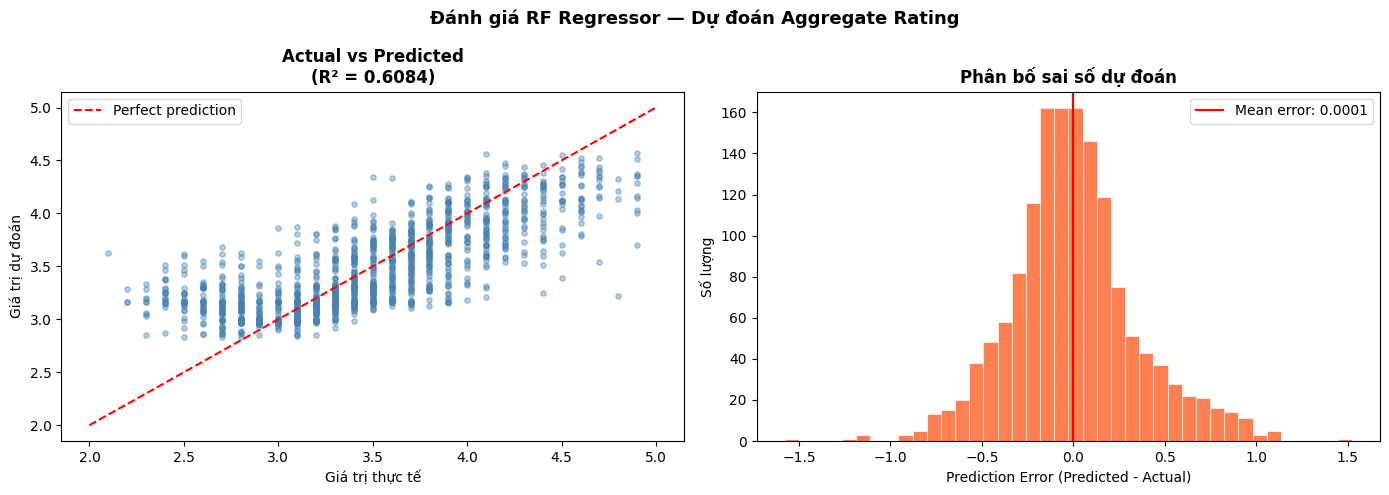

In [110]:
# Visualize: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_valid_r, y_pred_r, alpha=0.4, color='steelblue', s=15)
lims = [min(y_valid_r.min(), y_pred_r.min()) - 0.1,
        max(y_valid_r.max(), y_pred_r.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Giá trị thực tế')
axes[0].set_ylabel('Giá trị dự đoán')
axes[0].set_title(f'Actual vs Predicted\n(R² = {r2:.4f})', fontweight='bold')
axes[0].legend()

# Histogram of errors
errors = y_pred_r - y_valid_r.values
axes[1].hist(errors, bins=40, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(errors.mean(), color='red', linestyle='-', linewidth=1.5, label=f'Mean error: {errors.mean():.4f}')
axes[1].set_xlabel('Prediction Error (Predicted - Actual)')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân bố sai số dự đoán', fontweight='bold')
axes[1].legend()

plt.suptitle('Đánh giá RF Regressor — Dự đoán Aggregate Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

KIỂM TRA OVERFITTING CHO REGRESSION

In [111]:
check_overfitting(rf_model_r, X_train_r, y_train_r, X_valid_r, y_valid_r, task='regression')

Kiểm tra Overfitting cho mô hình: regression
MAE  - Train: 0.2561, Valid: 0.2592
R²   - Train: 0.6062, Valid: 0.6084
Mô hình ổn định (Gap giữa Train và Valid nhỏ).


FEATURE IMPORTANCE CỦA CLASSIFIER VÀ REGRESSOR

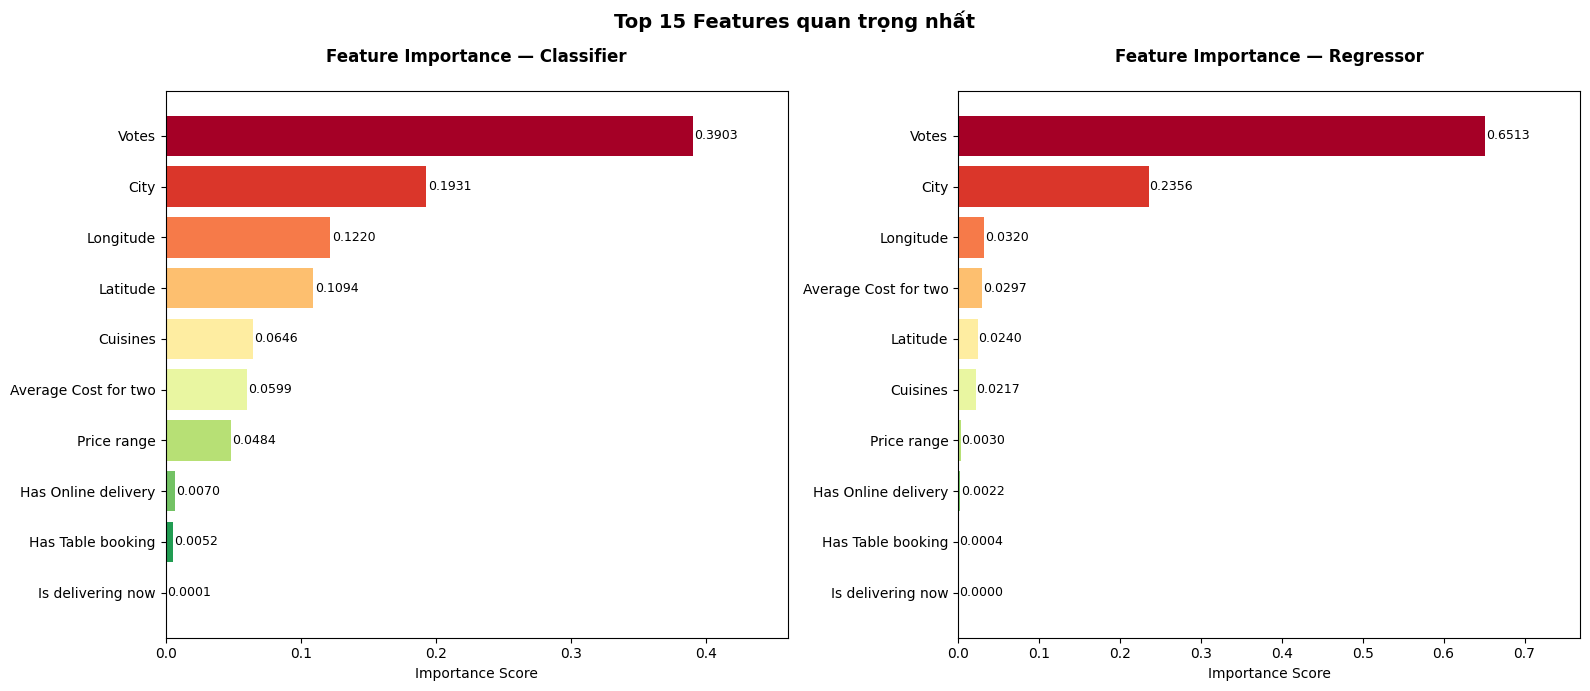

In [112]:
# Visualize
def plot_feature_importance(model, features, title, ax, top_n=15):
    importances = model.feature_importances_
    feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})\
                .sort_values('Importance', ascending=False).head(top_n)
    
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0, 1, len(feat_df)))
    bars = ax.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color=colors_bar)
    
    for bar, val in zip(bars, feat_df['Importance'][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    ax.set_xlabel('Importance Score')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, feat_df['Importance'].max() * 1.18)
    return feat_df

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feat_clf = plot_feature_importance(rf_model_c, features, 'Feature Importance — Classifier\n', axes[0])
feat_reg = plot_feature_importance(rf_model_r, features, 'Feature Importance — Regressor\n', axes[1])

plt.suptitle('Top 15 Features quan trọng nhất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()